# Cognifyz Machine Learning Internship

## Task 3 — Cuisine Classification

### Objective

Develop a machine learning classification model to classify
restaurants based on their cuisines.

### Approach

The Cuisines column contains multiple cuisines in some records.
Therefore, the first cuisine listed for each restaurant will be
used as the primary cuisine for classification.

Because some cuisines have very few observations, rare classes
will be grouped into an "Other" category to make the multiclass
classification problem more practical and stable.

### Important

The original Cuisines column will not be used as an input feature
because it directly contains the target information.

In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [40]:

df = pd.read_csv(
    "../outputs/results/cleaned_restaurant_dataset.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (9551, 22)


In [41]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Primary Cuisine
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,French
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Japanese
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Seafood
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Japanese
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Japanese


In [42]:
print("Missing cuisines:", df["Cuisines"].isna().sum())
print("Unique cuisine strings:", df["Cuisines"].nunique())

Missing cuisines: 0
Unique cuisine strings: 1826


In [43]:
df["Primary Cuisine"] = (
    df["Cuisines"]
    .fillna("Unknown")
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)

In [44]:
df[
    ["Cuisines", "Primary Cuisine"]
].head(20)

,Cuisines,Primary Cuisine
0,"French, Japanese, Desserts",French
1,Japanese,Japanese
2,"Seafood, Asian, Filipino, Indian",Seafood
3,"Japanese, Sushi",Japanese
4,"Japanese, Korean",Japanese
5,Chinese,Chinese
6,"Asian, European",Asian
7,"Seafood, Filipino, Asian, European",Seafood
8,"European, Asian, Indian",European
9,Filipino,Filipino


In [45]:
df["Primary Cuisine"] = (
    df["Primary Cuisine"]
    .str.strip()
    .str.title()
)

In [46]:
df["Primary Cuisine"].value_counts().head(20)

Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Name: count, dtype: int64

In [47]:
cuisine_counts = (
    df["Primary Cuisine"]
    .value_counts()
)

cuisine_counts.head(20)

Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Name: count, dtype: int64

In [48]:
cuisine_counts = (
    df["Primary Cuisine"]
    .value_counts()
)

cuisine_counts.head(20)

Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Name: count, dtype: int64

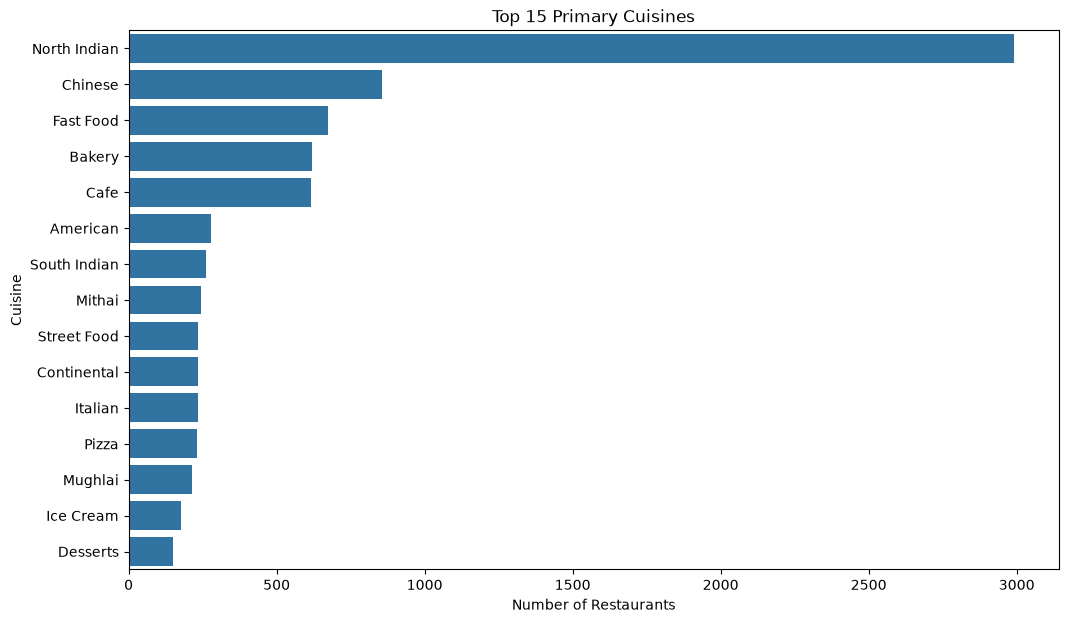

In [49]:
top_cuisines = (
    cuisine_counts
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title("Top 15 Primary Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.savefig(
    "../outputs/figures/task3_top_primary_cuisines.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [50]:
MIN_SAMPLES = 50

rare_cuisines = cuisine_counts[
    cuisine_counts < MIN_SAMPLES
]

print(
    "Number of rare cuisine classes:",
    len(rare_cuisines)
)

print(
    "Restaurants in rare classes:",
    rare_cuisines.sum()
)

Number of rare cuisine classes: 94
Restaurants in rare classes: 653


In [51]:
df["Cuisine Class"] = np.where(
    df["Primary Cuisine"].map(cuisine_counts) < MIN_SAMPLES,
    "Other",
    df["Primary Cuisine"]
)

In [52]:
df["Cuisine Class"].value_counts().head(20)

Cuisine Class
North Indian    2992
Chinese          855
Fast Food        672
Other            653
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Name: count, dtype: int64

In [53]:
print(
    "Final number of classes:",
    df["Cuisine Class"].nunique()
)

Final number of classes: 27


In [54]:
final_counts = (
    df["Cuisine Class"]
    .value_counts()
)

final_counts

Cuisine Class
North Indian    2992
Chinese          855
Fast Food        672
Other            653
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Asian             77
Japanese          72
European          62
Mexican           62
Healthy Food      56
Indian            51
Name: count, dtype: int64

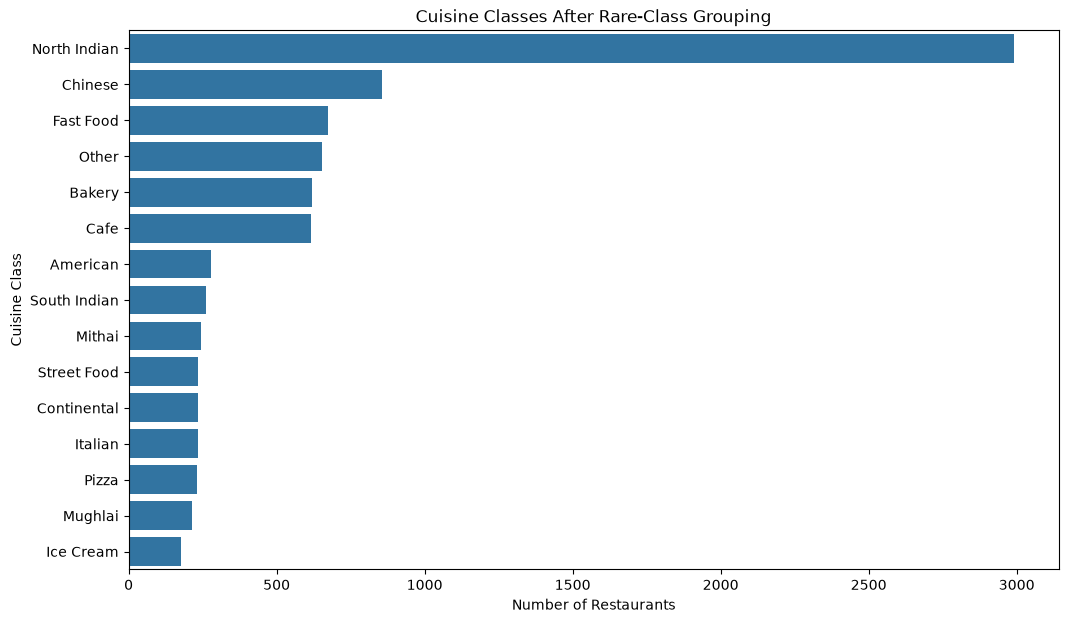

In [55]:
top_final = final_counts.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_final.values,
    y=top_final.index
)

plt.title("Cuisine Classes After Rare-Class Grouping")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Class")

plt.savefig(
    "../outputs/figures/task3_final_class_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [56]:
features = [
    "Country Code",
    "City",
    "Average Cost for two",
    "Currency",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Price range",
    "Aggregate rating",
    "Votes",
    "Latitude",
    "Longitude"
]

In [57]:
target = "Cuisine Class"

In [58]:
X = df[features].copy()

y = df[target].copy()

In [59]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9551, 12)
y shape: (9551,)


In [60]:
print("\nTarget distribution:")
print(y.value_counts())


Target distribution:
Cuisine Class
North Indian    2992
Chinese          855
Fast Food        672
Other            653
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Asian             77
Japanese          72
European          62
Mexican           62
Healthy Food      56
Indian            51
Name: count, dtype: int64


In [61]:
X.isnull().sum()

Country Code             0
City                     0
Average Cost for two    18
Currency                 0
Has Table booking        0
Has Online delivery      0
Is delivering now        0
Price range              0
Aggregate rating         0
Votes                    0
Latitude                 0
Longitude                0
dtype: int64

In [62]:
y.isnull().sum()

np.int64(0)

In [63]:
class_distribution = (
    y.value_counts(normalize=True) * 100
)

class_distribution.head(20).round(2)

Cuisine Class
North Indian    31.33
Chinese          8.95
Fast Food        7.04
Other            6.84
Bakery           6.50
Cafe             6.46
American         2.91
South Indian     2.74
Mithai           2.58
Street Food      2.47
Continental      2.46
Italian          2.45
Pizza            2.43
Mughlai          2.25
Ice Cream        1.86
Desserts         1.57
Burger           1.21
Biryani          1.17
Raw Meats        1.15
Beverages        0.83
Name: proportion, dtype: float64

In [64]:
print(
    "Unknown cuisine records:",
    (df["Cuisine Class"] == "Unknown").sum()
)

Unknown cuisine records: 0


In [65]:
df_classification = df[
    df["Cuisine Class"] != "Unknown"
].copy()

print(
    "Classification dataset shape:",
    df_classification.shape
)

Classification dataset shape: (9551, 23)


In [66]:
X = df_classification[features].copy()

y = df_classification[target].copy()

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [68]:
stratify=y

In [69]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7640
Testing samples: 1911


In [70]:
print("Training classes:", y_train.nunique())
print("Testing classes:", y_test.nunique())

Training classes: 27
Testing classes: 27


In [71]:
train_distribution = (
    y_train.value_counts(normalize=True) * 100
).round(2)

test_distribution = (
    y_test.value_counts(normalize=True) * 100
).round(2)

distribution_comparison = pd.DataFrame({
    "Train %": train_distribution,
    "Test %": test_distribution
}).fillna(0)

distribution_comparison

,Train %,Test %
Cuisine Class,,
American,2.91,2.93
Asian,0.81,0.78
Bakery,6.51,6.49
Beverages,0.82,0.84
Biryani,1.18,1.15
Burger,1.22,1.20
Cafe,6.45,6.49
Chinese,8.95,8.95
Continental,2.46,2.46


In [72]:
df_classification.to_csv(
    "../outputs/results/task3_classification_dataset.csv",
    index=False
)

In [73]:
final_counts.to_csv(
    "../outputs/results/task3_class_distribution.csv"
)

In [74]:
X_train.to_csv(
    "../outputs/results/task3_X_train.csv",
    index=False
)

X_test.to_csv(
    "../outputs/results/task3_X_test.csv",
    index=False
)

y_train.to_csv(
    "../outputs/results/task3_y_train.csv",
    index=False
)

y_test.to_csv(
    "../outputs/results/task3_y_test.csv",
    index=False
)

In [75]:
MIN_SAMPLES = 50

# Day 10 — Task 3 Progress

## Work Completed

- Loaded the cleaned restaurant dataset.
- Examined the Cuisines column.
- Created a Primary Cuisine feature from the first cuisine listed
  for each restaurant.
- Analyzed the distribution of cuisine classes.
- Identified the presence of rare cuisine classes.
- Grouped cuisines with fewer than 50 observations into an
  "Other" category.
- Removed restaurants with an Unknown cuisine label from the
  classification dataset.
- Selected restaurant, location, service, price, rating, and
  popularity-related attributes as input features.
- Excluded Cuisines and Primary Cuisine from the input features
  to avoid target leakage.
- Created X and y for the classification problem.
- Performed a stratified 80/20 train-test split.
- Saved the prepared classification dataset and split data.

## Classification Target

The target variable is `Cuisine Class`.

## Next Step

Train and compare classification algorithms such as Logistic
Regression and Random Forest, followed by evaluation using
accuracy, precision, recall, F1-score, and a confusion matrix.